In [22]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchsummary import summary

import time
import numpy as np
import matplotlib.pyplot as plt

torch.cuda.is_available()

True

In [23]:
#deine some constants
epoch = 10
batch = 128
learning_rate = 0.001

In [24]:
#define a transfrom to transform the images
transform = transforms.Compose([
    transforms.ToTensor(), #convert the the image into an tensor
    transforms.Normalize((0.5,),(0.5,)) #normalize the tensor
])

In [25]:
#load data
train_set = torchvision.datasets.FashionMNIST(root='./data_new', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root = './data_new', train=False, download=True, transform=transform)

#dataloader
trainloader = torch.utils.data.DataLoader(train_set, batch_size=batch, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(test_set, batch_size=batch, shuffle=False, num_workers=2)

Image shape:torch.Size([128, 1, 28, 28])
label shape:torch.Size([128])


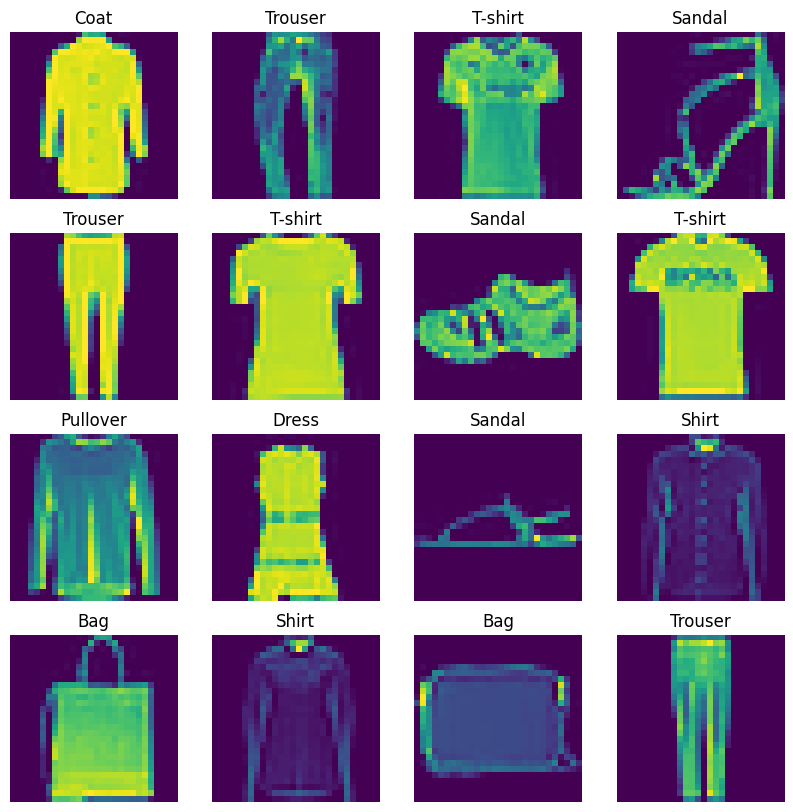

In [26]:
#visualize the images
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

for batch_1 in trainloader:
  batch = batch_1
  break

print(f"Image shape:{batch[0].shape}")#image pixels
print(f"label shape:{batch[1].shape}")#label=(batch,1)

plt.figure(figsize=(10,10))
for i in range(min(batch[0].shape[0], 16)): # Limit to 16 images for 4x4 subplot
  plt.subplot(4,4,i+1)
  plt.title(classes[batch[1][i]])
  plt.imshow(batch[0][i,0,:,:])
  plt.axis('off')
plt.show()

In [27]:
#build the CNN
class ImgNet(nn.Module):
  def __init__(self):
    super().__init__() # Call the parent class constructor
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)#what does kernel size mean?
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.fc1 = nn.Linear(in_features=256, out_features=120) # Corrected nn.linear and name to fc1
    self.fc2 = nn.Linear(in_features=120, out_features=84)  # Corrected nn.linear and name to fc2
    self.fc3 = nn.Linear(in_features=84, out_features=10)   # Corrected nn.linear and name to fc3

  def forward(self, x):
    x = F.relu(self.conv1(x))
    x = F.max_pool2d(x, kernel_size=2)
    x = F.relu(self.conv2(x))
    x = F.max_pool2d(x, kernel_size=2)
    x = x.view(x.size(0),-1)
    x = F.relu(self.fc1(x)) # Changed fn1 to fc1
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x
net = ImgNet()
print(net)

ImgNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [28]:
#displaying the model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(str(summary(net.to(device), (1,28,28), device=device.type)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
            Conv2d-2             [-1, 16, 8, 8]           2,416
            Linear-3                  [-1, 120]          30,840
            Linear-4                   [-1, 84]          10,164
            Linear-5                   [-1, 10]             850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.17
Estimated Total Size (MB): 0.21
----------------------------------------------------------------
None


In [29]:
#loss function
loss_fn = nn.CrossEntropyLoss()

#Optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [30]:
#function to calculate accuracy
def calc_acc(loader):
  correct = 0
  total = 0
  for data in loader:
    inputs, labels = data[0].to(device), data[1].to(device)
    outputs = net(inputs)
    _, predicted = torch.max(outputs.data, 1) # Extract only the predicted indices
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
  return ((100 * correct)/ total)

In [31]:
def training():
  epoch_loss = []
  train_acc = []
  test_acc = []

  for epochs in range(epoch):
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
      inputs, labels = data[0].to(device), data[1].to(device)
      optimizer.zero_grad()
      outputs = net(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()

    epoch_loss.append(running_loss)
    train_acc.append(calc_acc(trainloader))
    test_acc.append(calc_acc(testloader))
    print(f'Epoch {epochs+1} of {epoch}, train accuracy: {train_acc[-1]:.2f}, test accuracy: {test_acc[-1]:.2f}')

  return epoch_loss, train_acc, test_acc

In [32]:
start = time.time()
epoch_loss, train_acc, test_acc = training()
end = time.time()

print("%0.2f Minutes" %((end-start)/60))

Epoch 1 of 10, train accuracy: 79.91, test accuracy: 79.26
Epoch 2 of 10, train accuracy: 83.80, test accuracy: 82.57
Epoch 3 of 10, train accuracy: 86.70, test accuracy: 85.98
Epoch 4 of 10, train accuracy: 88.05, test accuracy: 86.87
Epoch 5 of 10, train accuracy: 88.30, test accuracy: 87.19
Epoch 6 of 10, train accuracy: 88.94, test accuracy: 87.51
Epoch 7 of 10, train accuracy: 89.86, test accuracy: 88.10
Epoch 8 of 10, train accuracy: 89.83, test accuracy: 87.96
Epoch 9 of 10, train accuracy: 90.08, test accuracy: 88.00
Epoch 10 of 10, train accuracy: 90.67, test accuracy: 88.52
4.38 Minutes


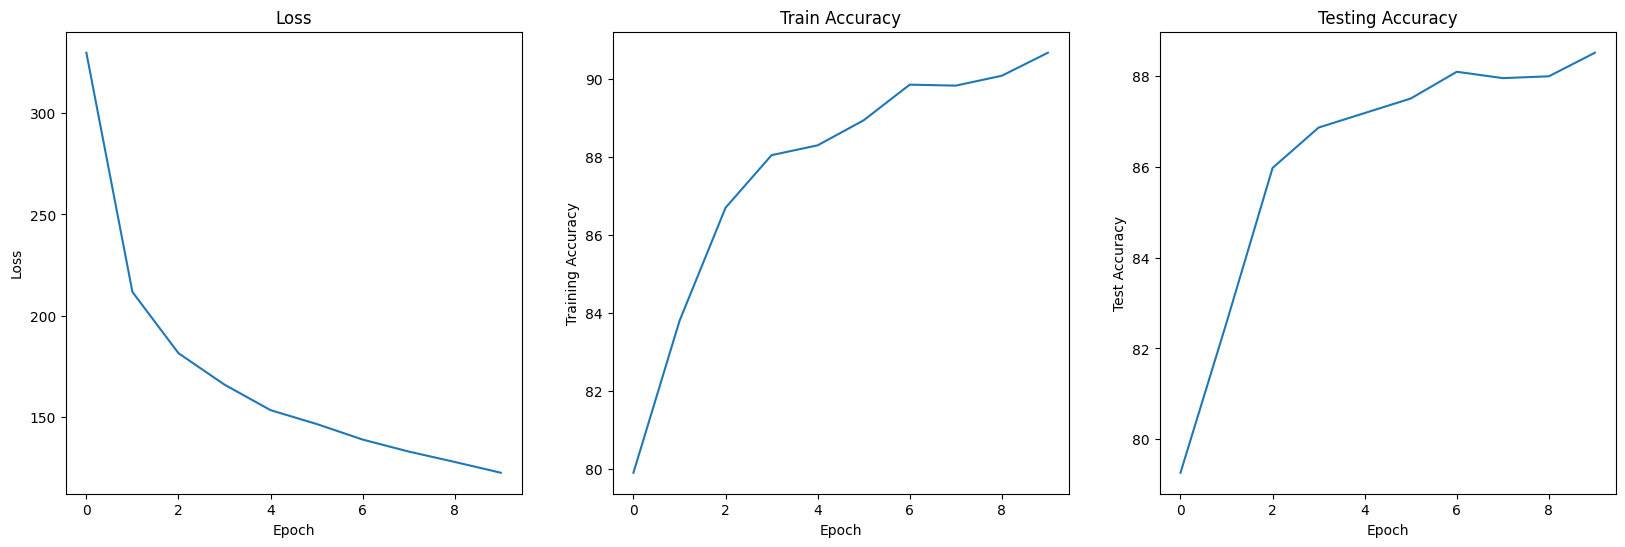

In [34]:
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
plt.plot(epoch_loss)
plt.title("Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,3,2)
plt.plot(train_acc)
plt.title("Train Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')

plt.subplot(1,3,3)
plt.plot(test_acc)
plt.title("Testing Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.show()